<a href="https://colab.research.google.com/github/ChiNonsoHenry16/Blood-Transfusion-and-AI-Models/blob/main/Classification_of_Reaction_Outcomes_in_Post_Blood_Transfusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of synthetic patients
n_samples = 5000

# Generate demographics
ages = np.random.randint(18, 90, size=n_samples)
sexes = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.5, 0.5])

# Generate hemoglobin levels (g/dL)
hemoglobin = np.random.normal(12.5 - (ages - 50) * 0.02, 1.2, n_samples).clip(7, 17)

# Transfused product type — ensure at least one of each
product_types = np.random.choice(['RBC', 'Platelets', 'Plasma'], size=n_samples - 3, p=[0.7, 0.2, 0.1])
# Force inclusion
product_types = np.append(product_types, ['RBC', 'Platelets', 'Plasma'])
np.random.shuffle(product_types)

# Pre transfusion vitals
pre_sbp = np.random.normal(120, 15, n_samples).clip(90, 180)
pre_temp = np.random.normal(36.8, 0.4, n_samples).clip(35.5, 38.5)

# Post transfusion vitals & reaction outcome
reaction_outcome = []
post_sbp = []
post_temp = []

for i in range(n_samples):
    sbp = pre_sbp[i]
    temp = pre_temp[i]
    hb = hemoglobin[i]
    product = product_types[i]

    risk = 0
    if hb < 9:
        risk += 0.2
    if product == 'Platelets':
        risk += 0.2
    if ages[i] > 70:
        risk += 0.1

    prob = min(0.1 + risk, 0.8)
    outcome = np.random.choice(['None', 'Mild', 'Moderate', 'Severe'], p=[1-prob, prob*0.7, prob*0.25, prob*0.05])
    reaction_outcome.append(outcome)

    if outcome == 'None':
        sbp_post = sbp + np.random.normal(0, 2)
        temp_post = temp + np.random.normal(0, 0.1)
    elif outcome == 'Mild':
        sbp_post = sbp - np.random.normal(5, 3)
        temp_post = temp + np.random.normal(0.5, 0.2)
    elif outcome == 'Moderate':
        sbp_post = sbp - np.random.normal(10, 5)
        temp_post = temp + np.random.normal(1.0, 0.3)
    else:
        sbp_post = sbp - np.random.normal(20, 5)
        temp_post = temp + np.random.normal(1.5, 0.5)

    post_sbp.append(sbp_post)
    post_temp.append(temp_post)

# Build DataFrame
df = pd.DataFrame({
    'Age': ages,
    'Sex': sexes,
    'Hemoglobin': hemoglobin.round(1),
    'Product_Type': product_types,
    'Pre_SBP': pre_sbp.round(1),
    'Pre_Temp': pre_temp.round(1),
    'Post_SBP': np.array(post_sbp).round(1),
    'Post_Temp': np.array(post_temp).round(1),
    'Reaction_Outcome': reaction_outcome
})

print(df['Product_Type'].value_counts())  # Confirm all 3 exist
df.head()


Product_Type
RBC          3453
Platelets    1020
Plasma        527
Name: count, dtype: int64


,Age,Sex,Hemoglobin,Product_Type,Pre_SBP,Pre_Temp,Post_SBP,Post_Temp,Reaction_Outcome
0,69,Female,11.7,RBC,132.9,36.3,132.4,36.3,None
1,32,Female,11.5,Plasma,130.4,37.0,129.0,37.0,None
2,89,Female,12.0,Platelets,98.7,37.4,92.9,37.9,Mild
3,78,Male,10.1,RBC,128.8,36.9,129.5,37.0,None
4,38,Male,12.8,Plasma,124.6,36.6,125.2,36.6,None


 Logistic Regression


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

        Mild       0.90      0.83      0.86       113
    Moderate       0.76      0.60      0.67        42
        None       0.98      1.00      0.99       836
      Severe       0.40      0.44      0.42         9

    accuracy                           0.96      1000
   macro avg       0.76      0.72      0.74      1000
weighted avg       0.96      0.96      0.96      1000



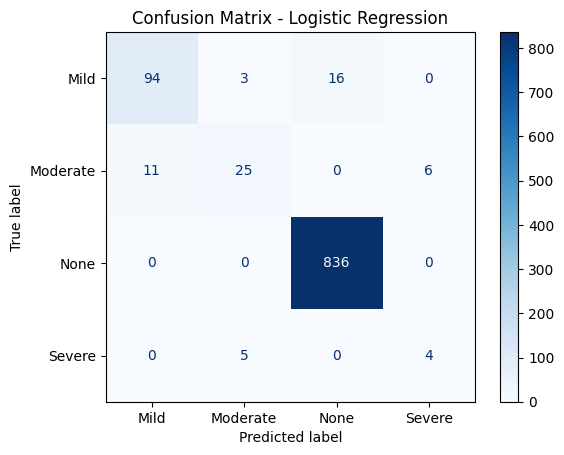

 Random Forest
              precision    recall  f1-score   support

        Mild       0.80      0.62      0.70       113
    Moderate       0.62      0.55      0.58        42
        None       0.96      1.00      0.98       836
      Severe       0.50      0.11      0.18         9

    accuracy                           0.93      1000
   macro avg       0.72      0.57      0.61      1000
weighted avg       0.92      0.93      0.92      1000



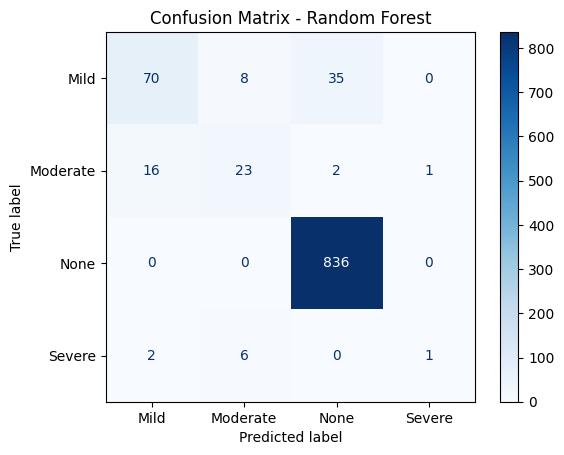

 Gradient Boosting
              precision    recall  f1-score   support

        Mild       0.84      0.79      0.81       113
    Moderate       0.71      0.60      0.65        42
        None       0.98      1.00      0.99       836
      Severe       0.56      0.56      0.56         9

    accuracy                           0.95      1000
   macro avg       0.77      0.73      0.75      1000
weighted avg       0.95      0.95      0.95      1000



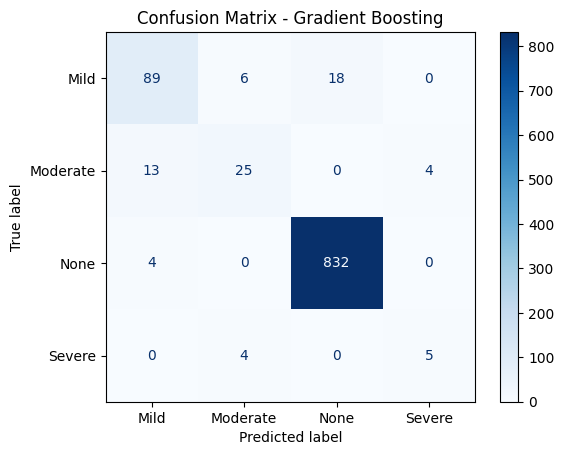

 XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:20:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

        Mild       0.84      0.85      0.85       113
    Moderate       0.78      0.67      0.72        42
        None       0.99      0.99      0.99       836
      Severe       0.88      0.78      0.82         9

    accuracy                           0.96      1000
   macro avg       0.87      0.82      0.84      1000
weighted avg       0.96      0.96      0.96      1000



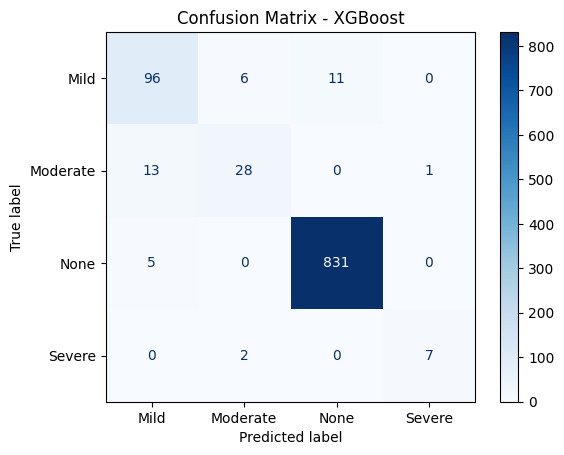

 Decision Tree
              precision    recall  f1-score   support

        Mild       0.70      0.73      0.72       113
    Moderate       0.51      0.43      0.47        42
        None       0.98      0.98      0.98       836
      Severe       0.56      0.56      0.56         9

    accuracy                           0.93      1000
   macro avg       0.69      0.67      0.68      1000
weighted avg       0.92      0.93      0.92      1000



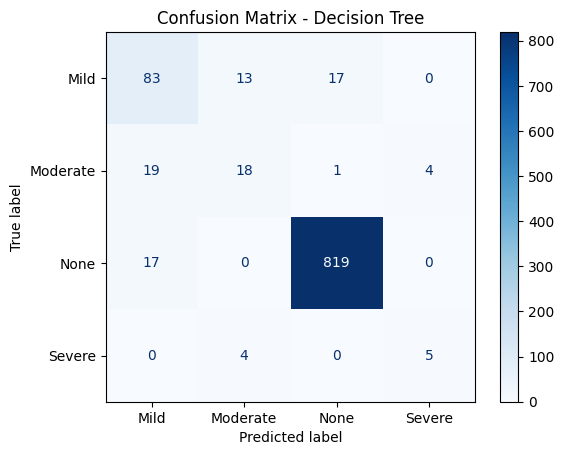

 SVM


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        Mild       0.00      0.00      0.00       113
    Moderate       0.00      0.00      0.00        42
        None       0.84      1.00      0.91       836
      Severe       0.00      0.00      0.00         9

    accuracy                           0.84      1000
   macro avg       0.21      0.25      0.23      1000
weighted avg       0.70      0.84      0.76      1000



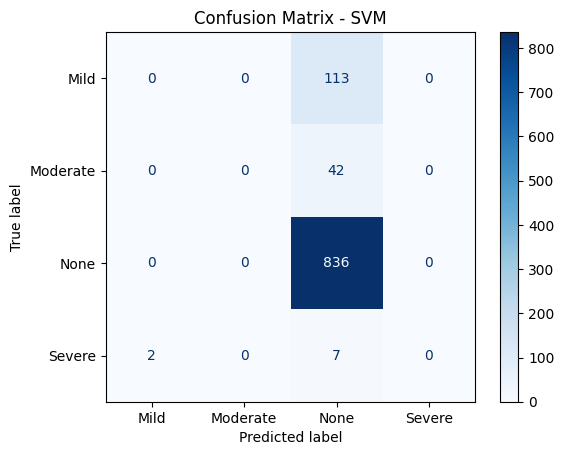

 KNN
              precision    recall  f1-score   support

        Mild       0.56      0.35      0.43       113
    Moderate       0.43      0.14      0.21        42
        None       0.91      1.00      0.95       836
      Severe       0.67      0.22      0.33         9

    accuracy                           0.88      1000
   macro avg       0.64      0.43      0.48      1000
weighted avg       0.85      0.88      0.86      1000



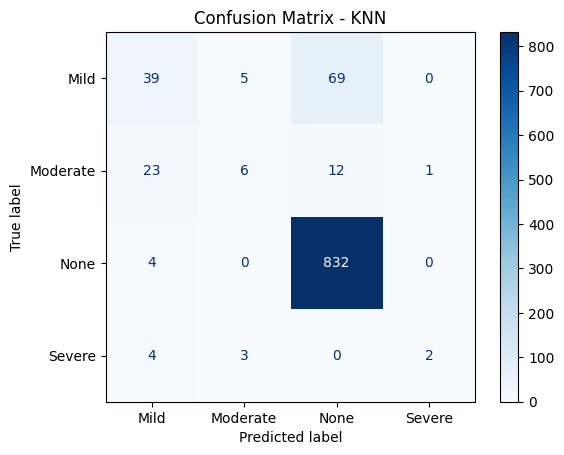

 Naive Bayes
              precision    recall  f1-score   support

        Mild       0.36      0.27      0.31       113
    Moderate       0.43      0.36      0.39        42
        None       0.91      0.95      0.93       836
      Severe       0.25      0.11      0.15         9

    accuracy                           0.84      1000
   macro avg       0.49      0.42      0.45      1000
weighted avg       0.82      0.84      0.83      1000



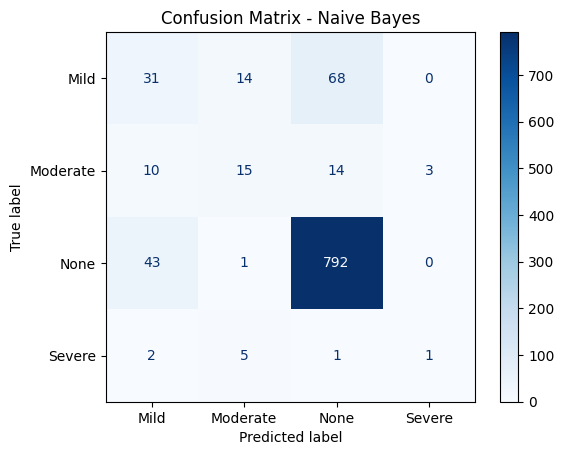

Model Accuracy Summary:
                 Model  Accuracy
3              XGBoost     0.962
0  Logistic Regression     0.959
2    Gradient Boosting     0.951
1        Random Forest     0.930
4        Decision Tree     0.925
6                  KNN     0.879
7          Naive Bayes     0.839
5                  SVM     0.836


In [2]:
# Import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

#  Encode Reaction_Outcome as integer labels
label_encoder = LabelEncoder()
df['Reaction_Outcome_Label'] = label_encoder.fit_transform(df['Reaction_Outcome'])

# Prepare classification features & target
X_cls = df[['Age', 'Hemoglobin', 'Pre_SBP', 'Pre_Temp', 'Post_SBP', 'Post_Temp']]
# Add one-hot for Product_Type
X_cls = pd.get_dummies(X_cls.join(df['Product_Type']), drop_first=True)

y_cls = df['Reaction_Outcome_Label']

# Split data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# Train & evaluate
results = []

for name, clf in classifiers.items():
    print(f" {name}")
    clf.fit(X_train_cls, y_train_cls)
    y_pred = clf.predict(X_test_cls)
    report = classification_report(y_test_cls, y_pred, target_names=label_encoder.classes_)
    print(report)
    results.append({
        "Model": name,
        "Accuracy": clf.score(X_test_cls, y_test_cls)
    })
    # Confusion Matrix
    cm = confusion_matrix(y_test_cls, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Show summary
results_df = pd.DataFrame(results)
print("Model Accuracy Summary:")
print(results_df.sort_values(by="Accuracy", ascending=False))


/tmp/ipython-input-3-2013358198.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classifiers))



 Logistic Regression
              precision    recall  f1-score   support

        Mild       0.90      0.83      0.86       113
    Moderate       0.76      0.60      0.67        42
        None       0.98      1.00      0.99       836
      Severe       0.40      0.44      0.42         9

    accuracy                           0.96      1000
   macro avg       0.76      0.72      0.74      1000
weighted avg       0.96      0.96      0.96      1000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 1000x800 with 0 Axes>

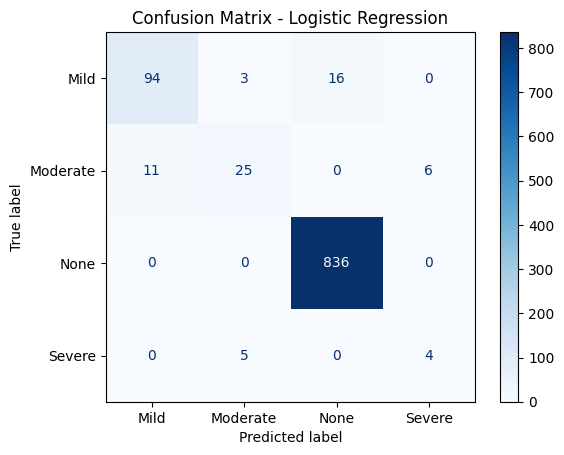


 Random Forest
              precision    recall  f1-score   support

        Mild       0.80      0.62      0.70       113
    Moderate       0.62      0.55      0.58        42
        None       0.96      1.00      0.98       836
      Severe       0.50      0.11      0.18         9

    accuracy                           0.93      1000
   macro avg       0.72      0.57      0.61      1000
weighted avg       0.92      0.93      0.92      1000



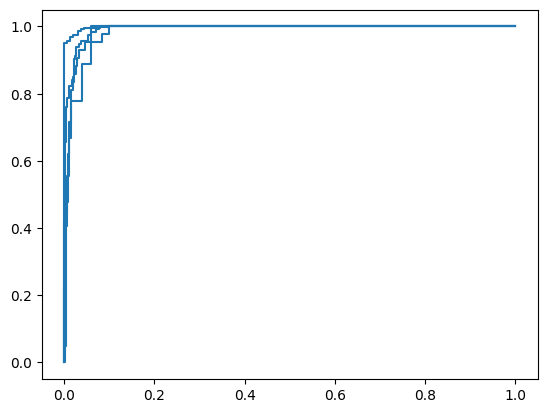

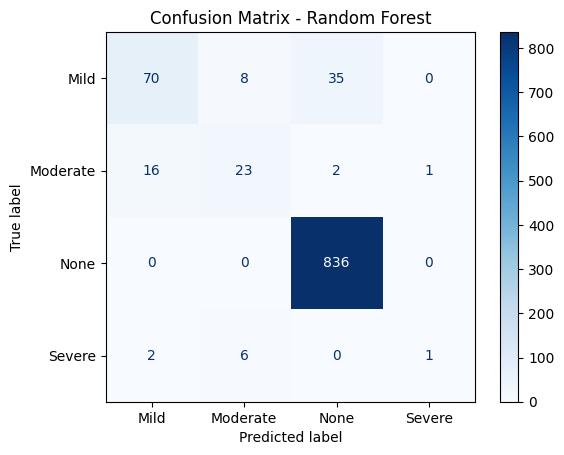


 Gradient Boosting
              precision    recall  f1-score   support

        Mild       0.84      0.79      0.81       113
    Moderate       0.71      0.60      0.65        42
        None       0.98      1.00      0.99       836
      Severe       0.56      0.56      0.56         9

    accuracy                           0.95      1000
   macro avg       0.77      0.73      0.75      1000
weighted avg       0.95      0.95      0.95      1000



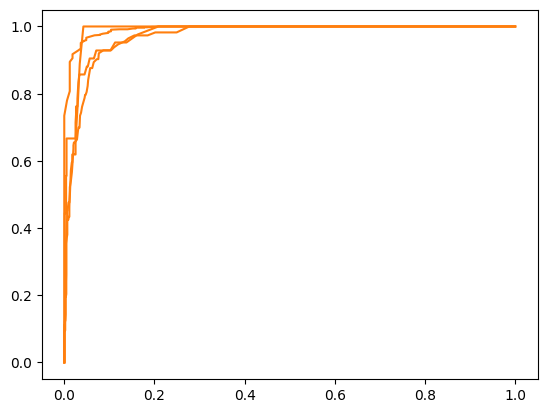

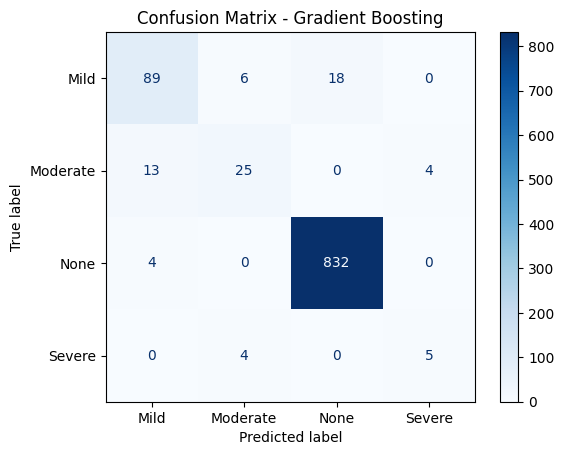


 XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:20:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

        Mild       0.84      0.85      0.85       113
    Moderate       0.78      0.67      0.72        42
        None       0.99      0.99      0.99       836
      Severe       0.88      0.78      0.82         9

    accuracy                           0.96      1000
   macro avg       0.87      0.82      0.84      1000
weighted avg       0.96      0.96      0.96      1000



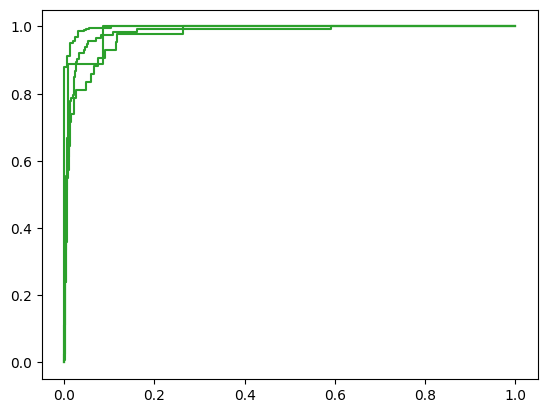

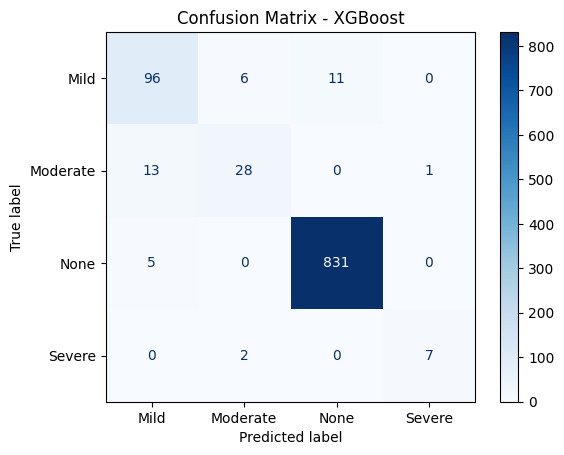


 Decision Tree
              precision    recall  f1-score   support

        Mild       0.70      0.73      0.72       113
    Moderate       0.51      0.43      0.47        42
        None       0.98      0.98      0.98       836
      Severe       0.56      0.56      0.56         9

    accuracy                           0.93      1000
   macro avg       0.69      0.67      0.68      1000
weighted avg       0.92      0.93      0.92      1000



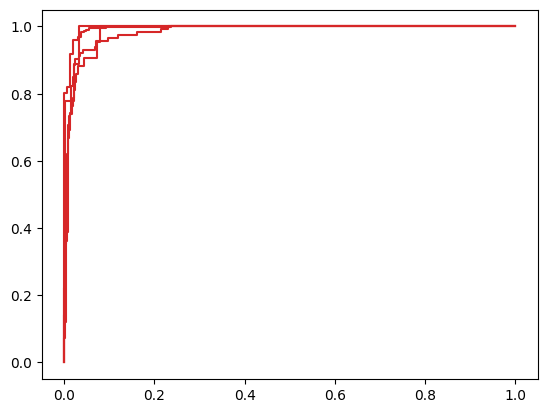

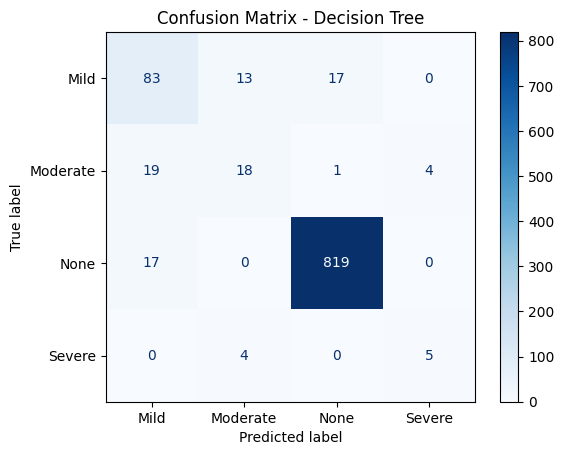


 SVM


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        Mild       0.00      0.00      0.00       113
    Moderate       0.00      0.00      0.00        42
        None       0.84      1.00      0.91       836
      Severe       0.00      0.00      0.00         9

    accuracy                           0.84      1000
   macro avg       0.21      0.25      0.23      1000
weighted avg       0.70      0.84      0.76      1000



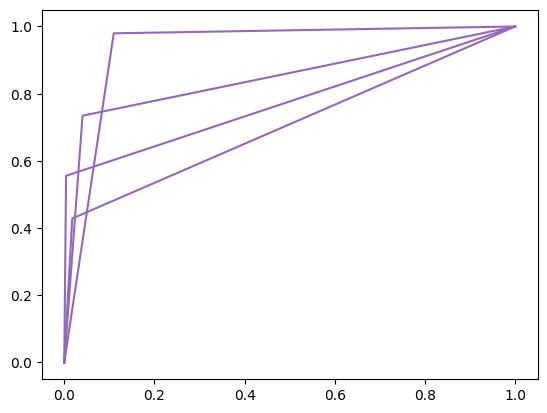

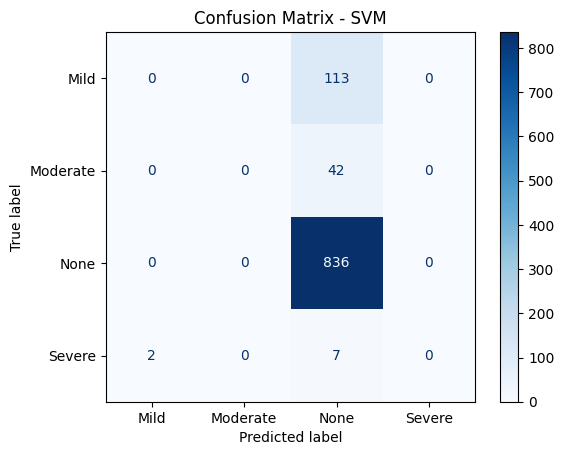


 KNN
              precision    recall  f1-score   support

        Mild       0.56      0.35      0.43       113
    Moderate       0.43      0.14      0.21        42
        None       0.91      1.00      0.95       836
      Severe       0.67      0.22      0.33         9

    accuracy                           0.88      1000
   macro avg       0.64      0.43      0.48      1000
weighted avg       0.85      0.88      0.86      1000



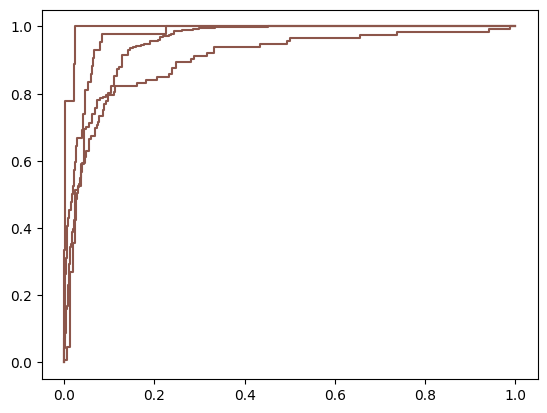

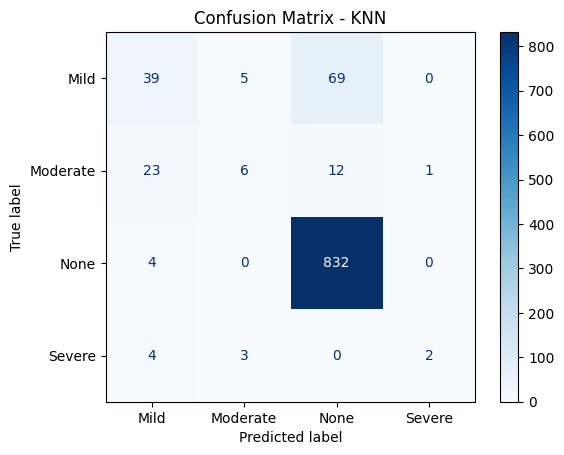


 Naive Bayes
              precision    recall  f1-score   support

        Mild       0.36      0.27      0.31       113
    Moderate       0.43      0.36      0.39        42
        None       0.91      0.95      0.93       836
      Severe       0.25      0.11      0.15         9

    accuracy                           0.84      1000
   macro avg       0.49      0.42      0.45      1000
weighted avg       0.82      0.84      0.83      1000



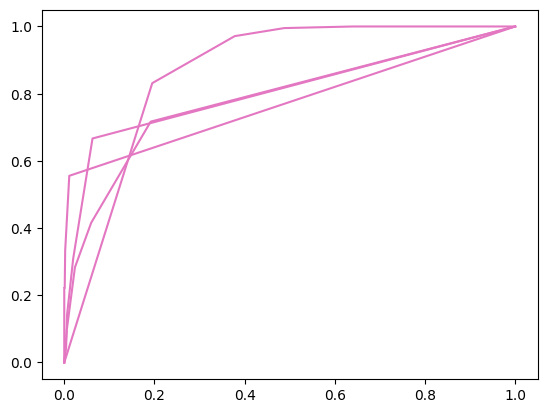

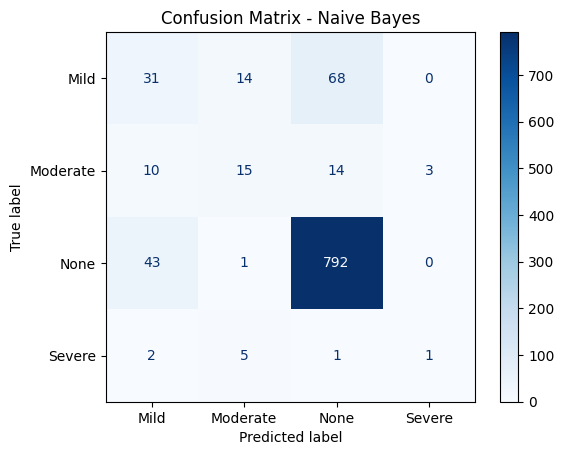


 AdaBoost
              precision    recall  f1-score   support

        Mild       0.49      0.79      0.60       113
    Moderate       0.70      0.62      0.66        42
        None       0.97      0.90      0.94       836
      Severe       0.00      0.00      0.00         9

    accuracy                           0.87      1000
   macro avg       0.54      0.58      0.55      1000
weighted avg       0.89      0.87      0.88      1000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


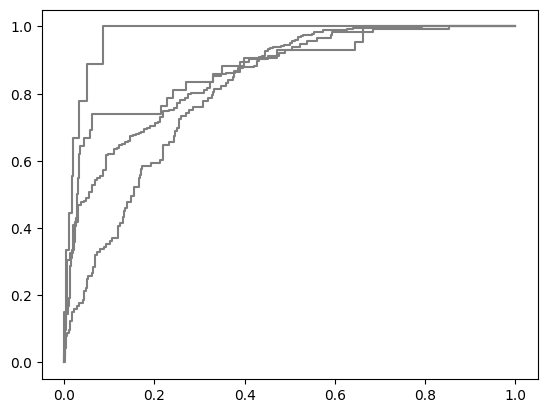

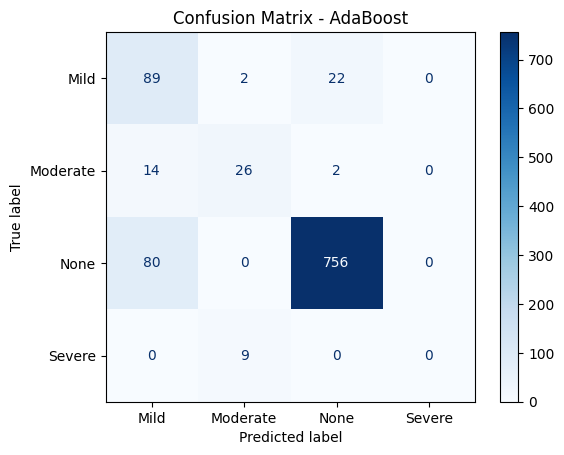


 Extra Trees
              precision    recall  f1-score   support

        Mild       0.74      0.44      0.55       113
    Moderate       0.67      0.52      0.59        42
        None       0.93      1.00      0.97       836
      Severe       0.75      0.33      0.46         9

    accuracy                           0.91      1000
   macro avg       0.77      0.57      0.64      1000
weighted avg       0.90      0.91      0.90      1000



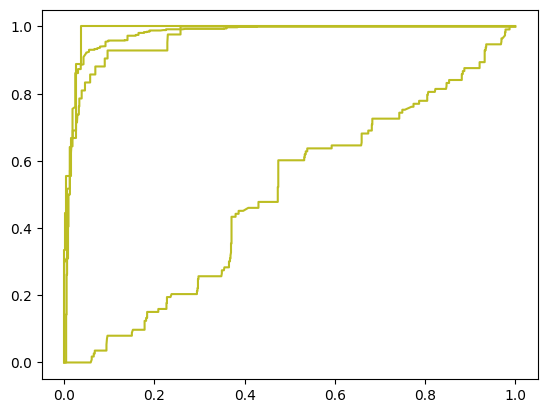

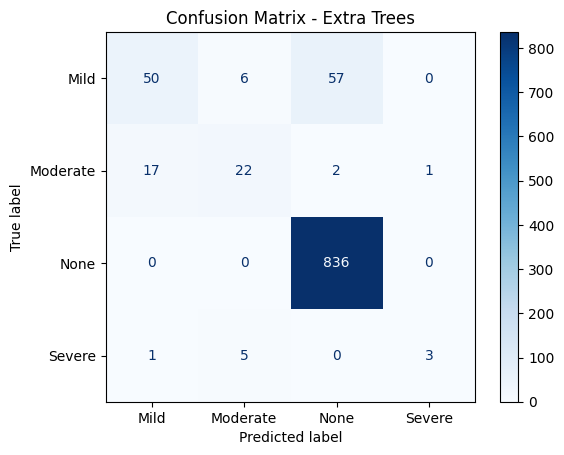

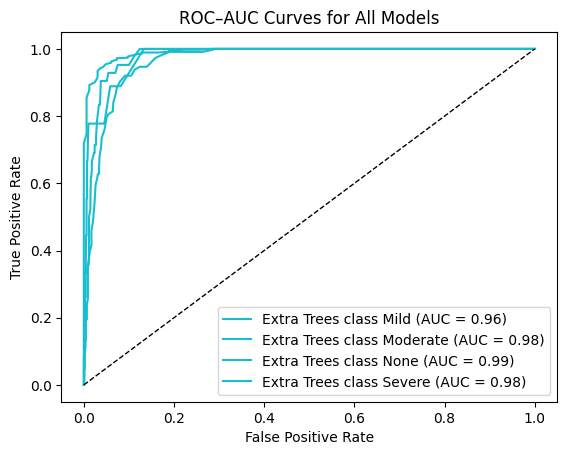

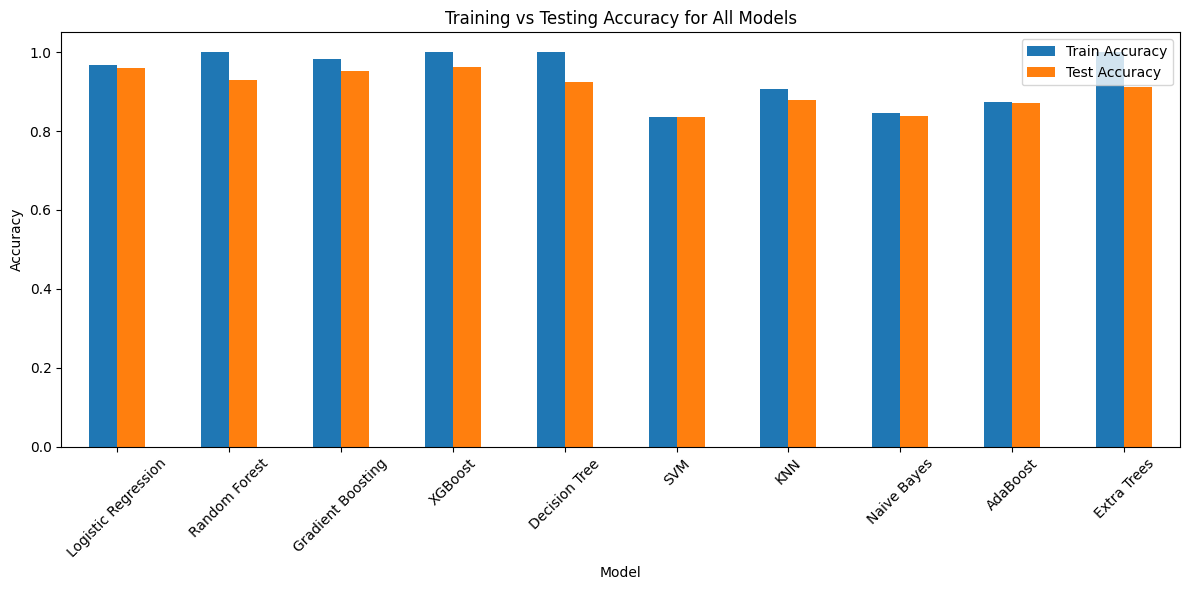

Plotting staged loss for Gradient Boosting...
Plotting staged loss for AdaBoost...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


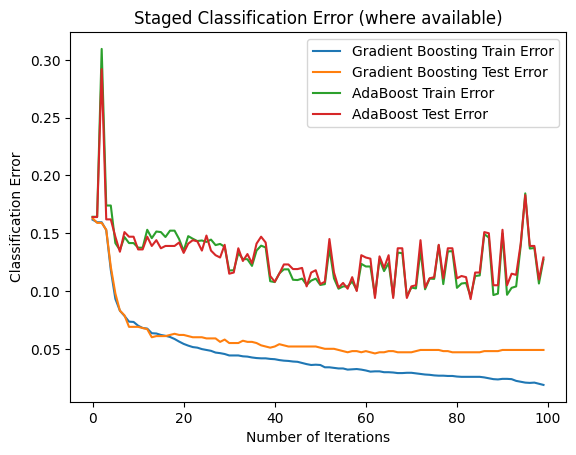

Classification Model Summary:
                 Model  Train Accuracy  Test Accuracy
3              XGBoost         1.00000          0.962
0  Logistic Regression         0.96850          0.959
2    Gradient Boosting         0.98125          0.951
1        Random Forest         1.00000          0.930
4        Decision Tree         1.00000          0.925
9          Extra Trees         1.00000          0.911
6                  KNN         0.90675          0.879
8             AdaBoost         0.87275          0.871
7          Naive Bayes         0.84650          0.839
5                  SVM         0.83575          0.836


In [3]:
# IMPORTS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay, accuracy_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ENCODE Reaction_Outcome
label_encoder = LabelEncoder()
df['Reaction_Outcome_Label'] = label_encoder.fit_transform(df['Reaction_Outcome'])

# FEATURES & TARGET
X_cls = df[['Age', 'Hemoglobin', 'Pre_SBP', 'Pre_Temp', 'Post_SBP', 'Post_Temp']]
X_cls = pd.get_dummies(X_cls.join(df['Product_Type']), drop_first=True)

y_cls = df['Reaction_Outcome_Label']
y_cls_bin = label_binarize(y_cls, classes=np.unique(y_cls))

# SPLIT
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# DEFINE 10 CLASSIFIERS
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42)
}

# TRAIN, EVALUATE, ROC–AUC, and LOSS PLOTS
results = []
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', len(classifiers))

for idx, (name, clf) in enumerate(classifiers.items()):
    print(f"\n {name}")
    clf.fit(X_train_cls, y_train_cls)
    y_pred = clf.predict(X_test_cls)
    acc_train = clf.score(X_train_cls, y_train_cls)
    acc_test = clf.score(X_test_cls, y_test_cls)
    report = classification_report(y_test_cls, y_pred, target_names=label_encoder.classes_)
    print(report)
    results.append({
        "Model": name,
        "Train Accuracy": acc_train,
        "Test Accuracy": acc_test
    })
    # Confusion Matrix
    cm = confusion_matrix(y_test_cls, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC–AUC Curve for multi-class
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test_cls)
    else:
        y_score = clf.decision_function(X_test_cls)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(y_cls_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(label_binarize(y_test_cls, classes=np.unique(y_cls))[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{name} class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})',
                 color=colors(idx))

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curves for All Models')
plt.legend()
plt.show()

# TRAIN vs TEST ACCURACY PLOT
results_df = pd.DataFrame(results)
results_df.plot(x='Model', y=['Train Accuracy', 'Test Accuracy'],
                kind='bar', figsize=(12, 6), rot=45)
plt.title('Training vs Testing Accuracy for All Models')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# PLOT LOSS CURVES for models that have it (XGB, GBDT, AdaBoost)
for name, clf in classifiers.items():
    if hasattr(clf, 'staged_predict_proba') or hasattr(clf, 'staged_predict'):
        print(f"Plotting staged loss for {name}...")
        train_errors = []
        test_errors = []
        for y_pred_train in clf.staged_predict(X_train_cls):
            train_errors.append(1 - accuracy_score(y_train_cls, y_pred_train))
        for y_pred_test in clf.staged_predict(X_test_cls):
            test_errors.append(1 - accuracy_score(y_test_cls, y_pred_test))
        plt.plot(train_errors, label=f"{name} Train Error")
        plt.plot(test_errors, label=f"{name} Test Error")
plt.title("Staged Classification Error (where available)")
plt.xlabel("Number of Iterations")
plt.ylabel("Classification Error")
plt.legend()
plt.show()

# FINAL TABLE
print("Classification Model Summary:")
print(results_df.sort_values(by="Test Accuracy", ascending=False))


Explainability with LIME

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=86d7de4a3e456a6b3efa4e43c5d8be140afbe3a3c130664555c9a5034d3a7239
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime

 LIME explanations for each classifier (one test sample each)...

Explaining Logistic Regression ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

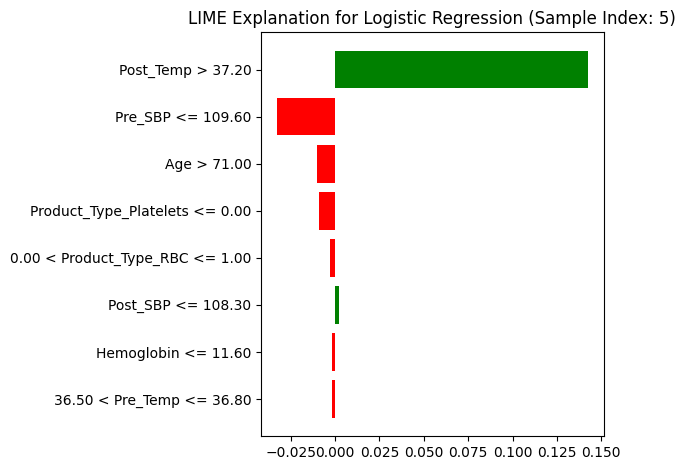


Explaining Random Forest ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

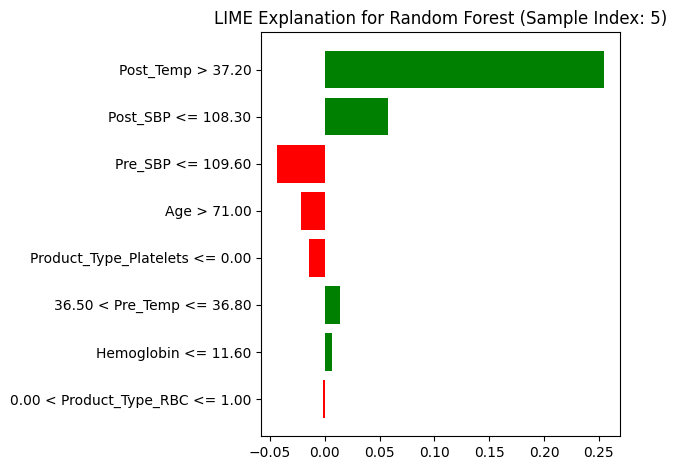


Explaining Gradient Boosting ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

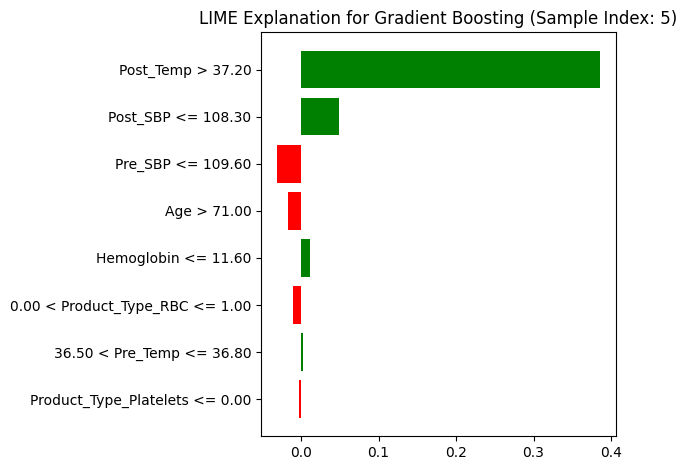


Explaining XGBoost ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

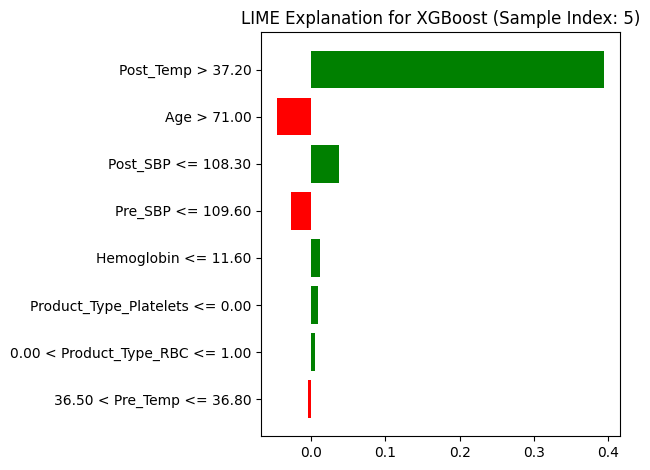


Explaining Decision Tree ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

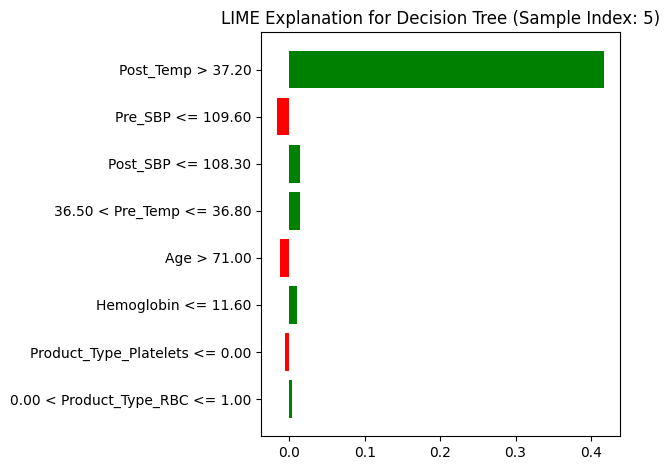


Explaining SVM ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

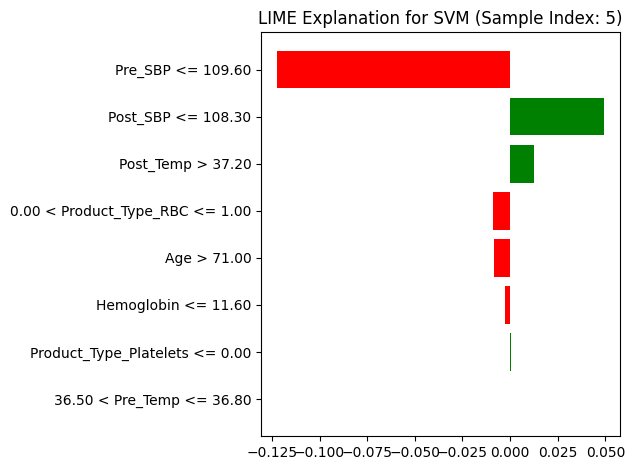


Explaining KNN ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

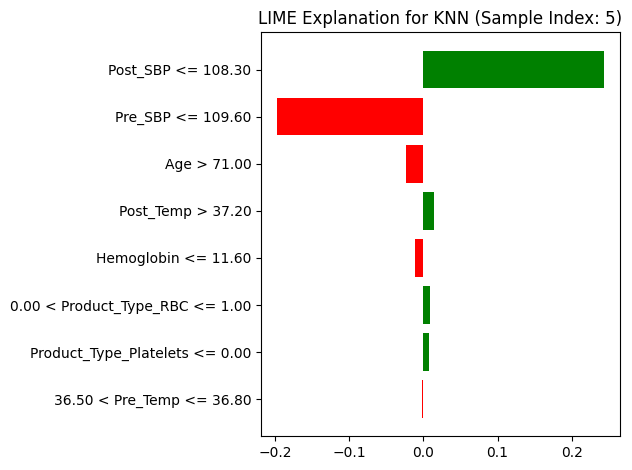


Explaining Naive Bayes ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

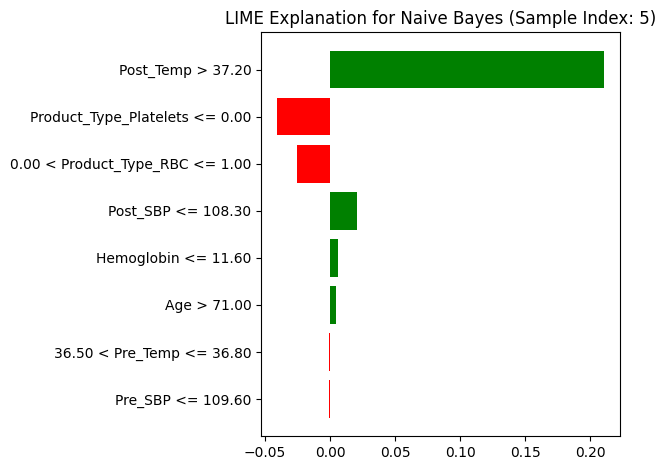


Explaining AdaBoost ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

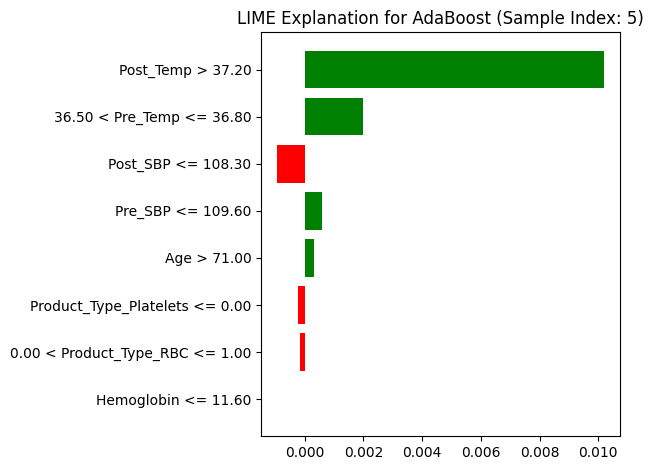


Explaining Extra Trees ...


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

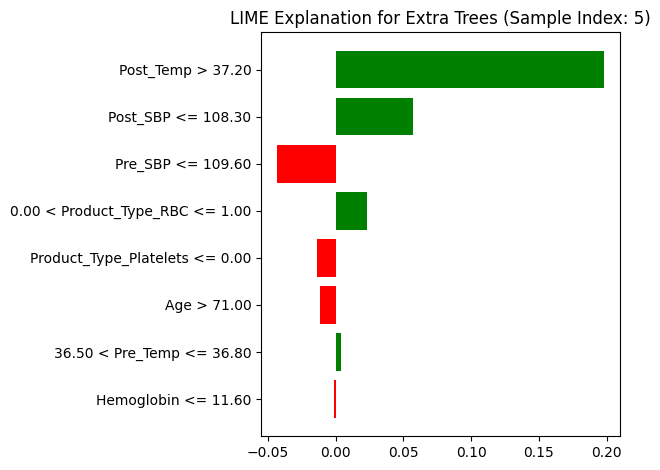

In [4]:
# LIME EXPLAINABILITY
!pip install lime

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

print("\n LIME explanations for each classifier (one test sample each)...")

# Initialize LIME explainer for classification
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_cls),
    feature_names=X_train_cls.columns.tolist(),
    class_names=label_encoder.classes_.tolist(),
    mode='classification'
)

# Pick an arbitrary test sample (you can change the index)
idx = 5

for name, clf in classifiers.items():
    print(f"\nExplaining {name} ...")

    # LIME explain instance for selected sample
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test_cls.iloc[idx],
        predict_fn=clf.predict_proba if hasattr(clf, "predict_proba") else clf.decision_function
    )

    # Show inline and save to file
    fig = lime_exp.as_pyplot_figure()
    plt.title(f"LIME Explanation for {name} (Sample Index: {idx})")
    plt.tight_layout()
    plt.savefig(f"lime_explanation_{name.replace(' ', '_')}.png")
    plt.show()
